In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df2 = pd.read_csv("data/combined_data.csv")
print(df2.columns)
exclude = ["price", "id", "name", "description", "amenities"]
all_features = [col for col in df2.columns if col not in exclude]


Index(['id', 'price', 'property_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'neighbourhood_cleansed', 'latitude', 'longitude',
       'minimum_nights', 'maximum_nights', 'instant_bookable',
       'availability_365', 'number_of_reviews', 'review_scores_rating',
       'review_scores_cleanliness', 'review_scores_location',
       'review_scores_value', 'reviews_per_month', 'host_is_superhost',
       'host_response_rate', 'host_total_listings_count', 'name',
       'description', 'amenities', 'room_type_Entire home/apt',
       'room_type_Hotel room', 'room_type_Private room',
       'room_type_Shared room', 'booked_days', 'booked_weekdays',
       'booked_weekenddays', 'booked_winter', 'booked_spring', 'booked_summer',
       'booked_fall', 'booked_range'],
      dtype='object')


In [5]:
X_all = df2[all_features]
y_all = df2["price"]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

In [7]:
feature_sets = {
    "ohne_calendar": [f for f in all_features if not f.startswith("booked")],
    "nur_calendar": ["booked_days", "booked_winter", "booked_summer", "booked_spring", "booked_fall", "booked_weekdays", "booked_weekenddays"],
    "calendar_plus_basics": [f for f in all_features if not f.startswith("booked") ] + ["booked_spring", "booked_fall", "booked_summer", "booked_winter"],
    "calendar_plus_basics2": [f for f in all_features if not f.startswith("booked") ] +  [ "booked_weekdays", "booked_weekenddays"],
    "calendar_plus_basics3": [f for f in all_features if not f.startswith("booked") ] +  ["booked_days"],
    "calendar_plus_basics4": [f for f in all_features if not f.startswith("booked") and f != "availability_365" ] +  ["booked_range"],
    "calendar_plus_basics5": [f for f in all_features if not f.startswith("booked") and f != "availability_365" ] +  ["booked_range", "booked_summer"],
    "alle_features": all_features
}

results = []

for name, features in feature_sets.items():
    print(f"Teste Feature-Set: {name}")

    X_train = X_train_all[features]
    X_test = X_test_all[features]

    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train_all)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test_all, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_all, y_pred))

    results.append({
        "feature_set": name,
        "MAE": mae,
        "RMSE": rmse
    })

    #feature_importance = pd.Series(
    #model.feature_importances_,
    #index=X.columns
    #).sort_values(ascending=False)


    #feature_importance.plot(kind="barh")
    #plt.title(f"Feature Importance {name}")
    #plt.xlabel("Wichtigkeit")
    #plt.tight_layout()

# Ergebnisse anzeigen
results_df = pd.DataFrame(results)
print(results_df)

Teste Feature-Set: ohne_calendar
Teste Feature-Set: nur_calendar
Teste Feature-Set: calendar_plus_basics
Teste Feature-Set: calendar_plus_basics2
Teste Feature-Set: calendar_plus_basics3
Teste Feature-Set: calendar_plus_basics4
Teste Feature-Set: calendar_plus_basics5
Teste Feature-Set: alle_features
             feature_set        MAE        RMSE
0          ohne_calendar  41.124812   76.880919
1           nur_calendar  76.819196  117.900155
2   calendar_plus_basics  42.064505   76.746527
3  calendar_plus_basics2  41.665851   76.793701
4  calendar_plus_basics3  41.713059   76.748942
5  calendar_plus_basics4  41.485242   76.984905
6  calendar_plus_basics5  41.677640   77.094661
7          alle_features  42.361110   77.522005


In [28]:
features = feature_sets["calendar_plus_basics2"]

In [29]:
# Funktion zum Testen von Hyperparametern
def test_hyperparameter(param_name, param_values, features):
    mae_scores = []
    rmse_scores = []

    X_train = X_train_all[features]
    X_test = X_test_all[features]

    for val in param_values:
        print(val)

        # Basis-Parameter
        params = {
            "random_state": 42
        }

        if param_name != "n_estimators":
            params["n_estimators"] = 300

        # Den zu testenden Parameter setzen
        params[param_name] = val

        model = RandomForestRegressor(**params)
        model.fit(X_train, y_train_all)
        y_pred = model.predict(X_test)

        mae_scores.append(mean_absolute_error(y_test_all, y_pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y_test_all, y_pred)))

    print(mae_scores)
    print(rmse_scores)

    if param_name != "max_features":
        plt.figure(figsize=(10,5))
        plt.plot(param_values, mae_scores, marker="o", label="MAE")
        plt.plot(param_values, rmse_scores, marker="o", label="RMSE")
        plt.title(f"Einfluss von {param_name} auf MAE/RMSE")
        plt.xlabel(param_name)
        plt.ylabel("Fehler")
        plt.grid(True)
        plt.legend()
        plt.show()

50
100
200
300
400
[42.1445244504262, 41.79385430686406, 41.48524170031404, 41.72538894763827, 41.66370383499968]
[np.float64(78.11990600827224), np.float64(77.5691217547427), np.float64(76.98490528904271), np.float64(77.27354998442591), np.float64(77.13232916700899)]


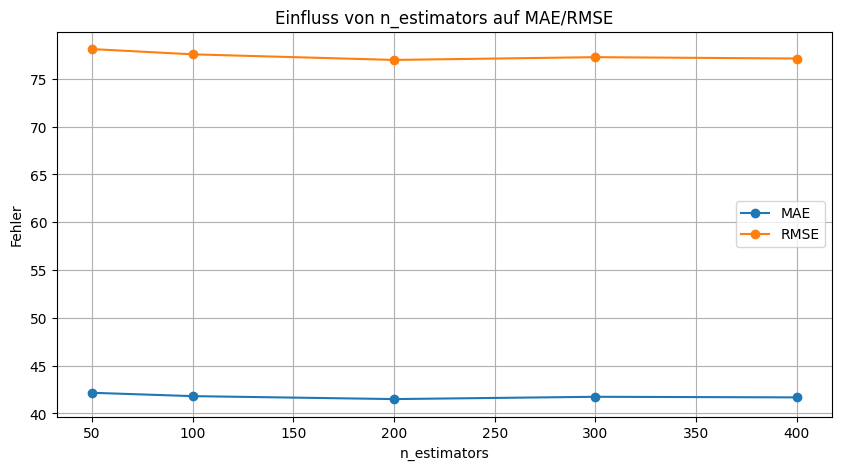

In [30]:
test_hyperparameter(
    "n_estimators",
    [50, 100, 200, 300, 400],
    feature_sets["calendar_plus_basics4"]
)

None
10
20
40
60
[41.72538894763827, 44.100032115852095, 41.891400804392845, 41.72557769548675, 41.72538894763827]
[np.float64(77.27354998442591), np.float64(78.86107046016255), np.float64(77.27325222478642), np.float64(77.27902178263334), np.float64(77.27354998442591)]


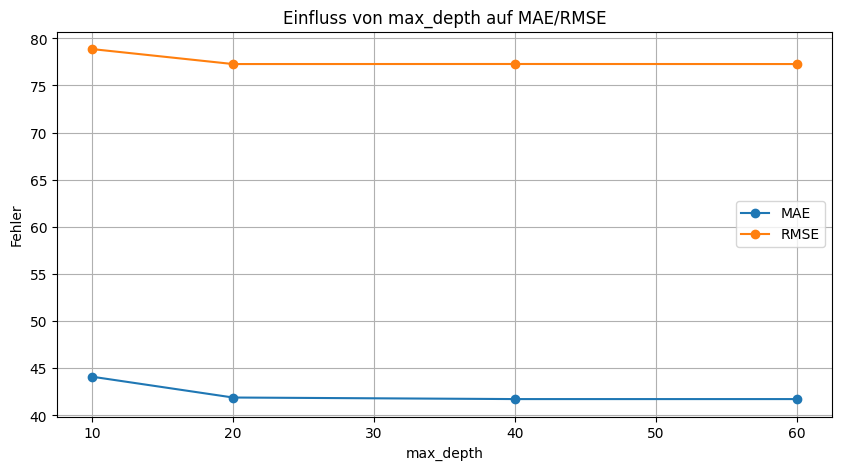

In [31]:
test_hyperparameter(
    "max_depth",
    [None, 10, 20, 40, 60],
    feature_sets["calendar_plus_basics4"]
)

2
5
10
20
[41.72538894763827, 41.908803466786516, 42.41326184696261, 42.68521071212791]
[np.float64(77.27354998442591), np.float64(77.19882588193704), np.float64(77.80082859228014), np.float64(77.69377967881307)]


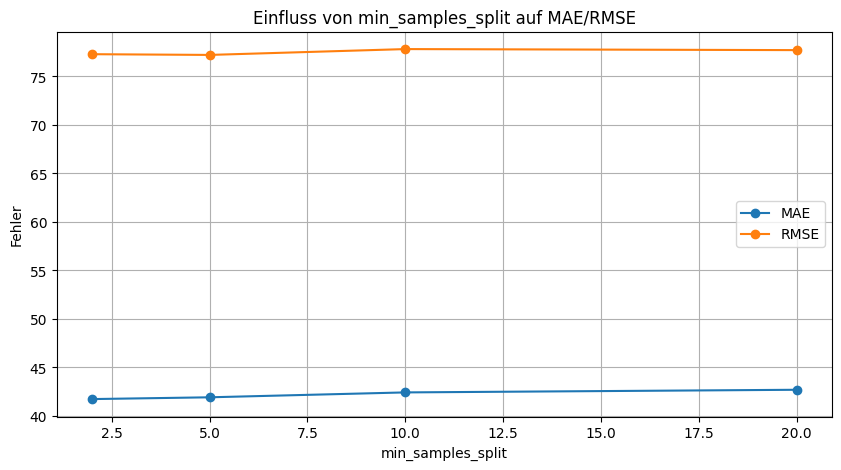

In [32]:
test_hyperparameter(
    "min_samples_split",
    [2, 5, 10, 20],
    feature_sets["calendar_plus_basics4"]
)

In [33]:
test_hyperparameter(
    "max_features",
    ["sqrt", "log2", None, 0.5],
    feature_sets["calendar_plus_basics4"]
)

sqrt
log2
None
0.5
[40.54693995812771, 40.8380062274349, 41.72538894763827, 41.17617429340511]
[np.float64(74.56639847223052), np.float64(75.18395250629375), np.float64(77.27354998442591), np.float64(75.40810176620279)]


MAE: 41.01332270597466
RMSE: 74.7130301841534


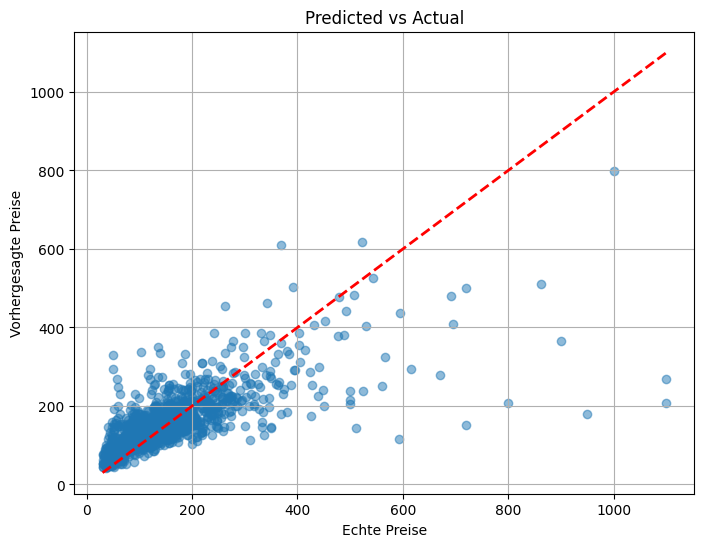

In [38]:
# daraus resultiert: n_estimator = 200, max_depth = 20, min_samples_split =2, max_features = sqrt

X_train = X_train_all[feature_sets["calendar_plus_basics2"]]
X_test = X_test_all[feature_sets["calendar_plus_basics2"]]

final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42
)

final_model.fit(X_train, y_train_all)
y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test_all, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_all, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(8,6))
plt.scatter(y_test_all, y_pred, alpha=0.5)
plt.plot([y_test_all.min(), y_test_all.max()],
         [y_test_all.min(), y_test_all.max()],
         "r--", lw=2)
plt.xlabel("Echte Preise")
plt.ylabel("Vorhergesagte Preise")
plt.title("Predicted vs Actual")
plt.grid(True)
plt.show()



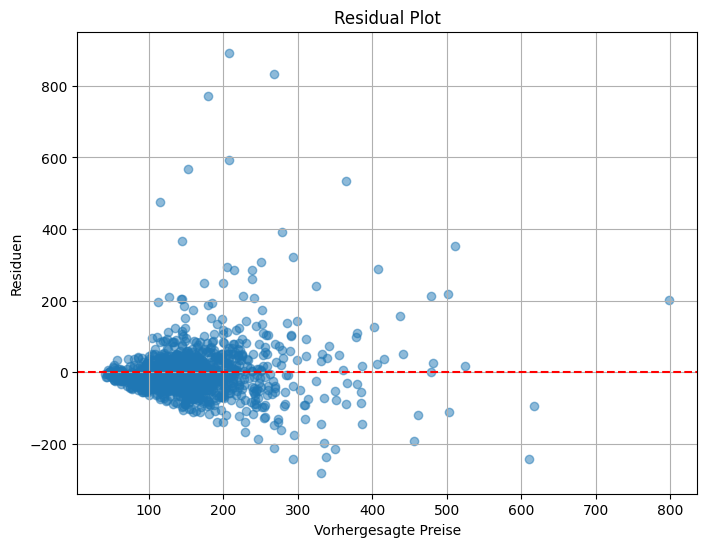

In [39]:
#Plot 2: Residuen‑Plot (Fehlerverteilung)
residuals = y_test_all - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Vorhergesagte Preise")
plt.ylabel("Residuen")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

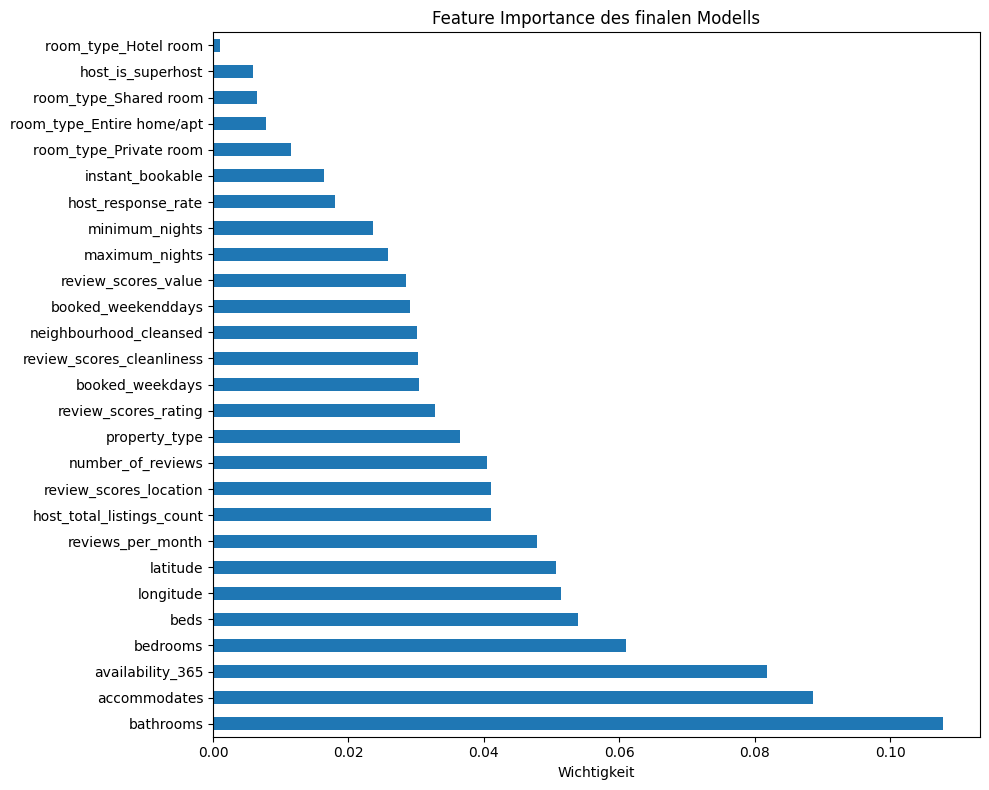

In [40]:
# feature importance
importances = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))
importances.plot(kind="barh")
plt.title("Feature Importance des finalen Modells")
plt.xlabel("Wichtigkeit")
plt.tight_layout()
plt.show()

In [37]:
df2.head

<bound method NDFrame.head of                        id  price  property_type  accommodates  bathrooms  \
0                   49287   93.0             11             3        1.0   
1                  108236  120.0             11             5        1.0   
2                  111140   89.0              4             4        1.0   
3                  179629  146.0             11             5        1.0   
4                  207702   85.0             11             2        1.0   
...                   ...    ...            ...           ...        ...   
7421  1516965602140848355  168.0              7             6        1.0   
7422  1517509437591056583  320.0             11            10        2.0   
7423  1517531428314685515  203.0             11             5        2.0   
7424  1517870021729485522  111.0             11             4        1.0   
7425  1518678870977149978   91.0             11             4        1.0   

      bedrooms  beds  neighbourhood_cleansed   latitude  